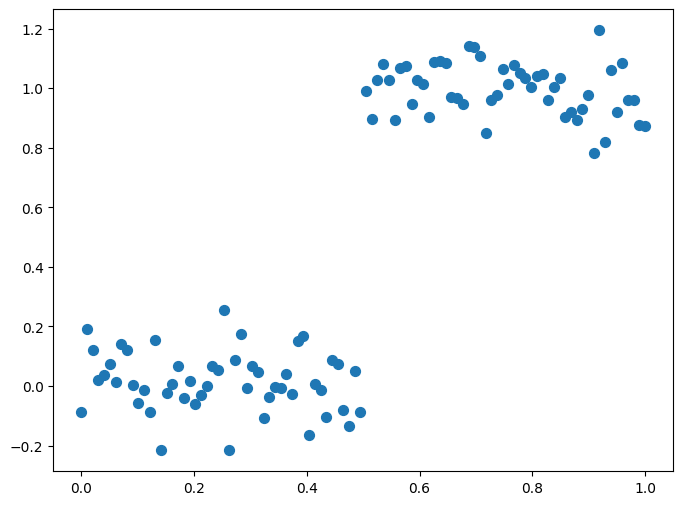

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_train = np.linspace(0, 1, 100)
X_test = np.linspace(0, 1, 1000)

@np.vectorize
def target(x):
  return x > 0.5

y_train = target(X_train) + np.random.randn(*X_train.shape) * 0.1

plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, s=50)
plt.show()

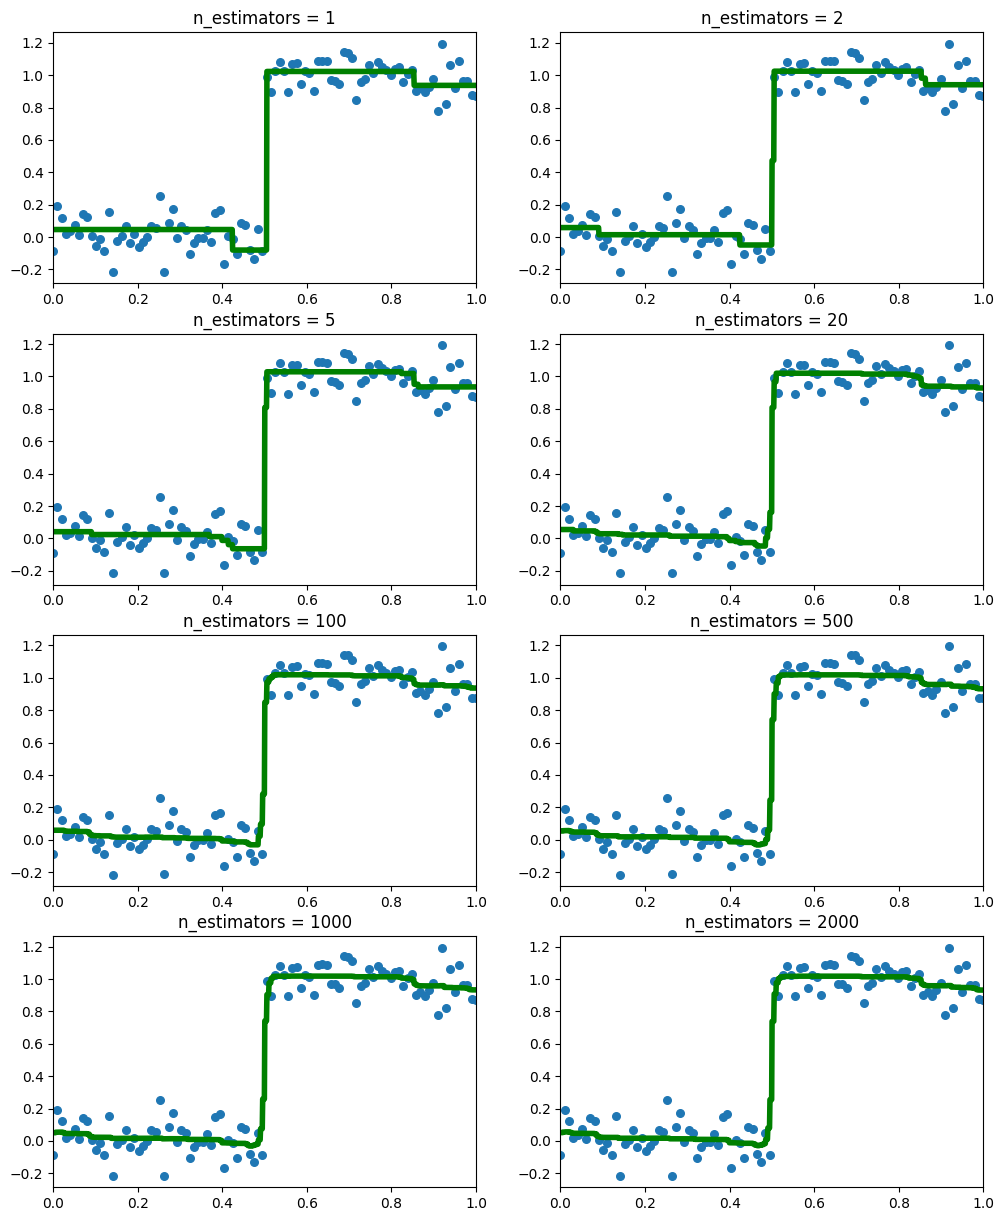

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor

reg = BaggingRegressor(DecisionTreeRegressor(max_depth=2), warm_start=True)
plt.figure(figsize=(12, 15))

sizes = [1, 2, 5, 20, 100, 500, 1000, 2000]
for i, s in enumerate(sizes):
  reg.n_estimators = s
  reg.fit(X_train.reshape(-1, 1), y_train)
  plt.subplot(4, 2, i + 1)
  plt.xlim([0, 1])
  plt.scatter(X_train, y_train, s=30)
  y_pred = reg.predict(X_test.reshape(-1, 1))
  plt.plot(X_test, y_pred, c='green', linewidth=4)
  plt.title(f'n_estimators = {s}')
plt.show()

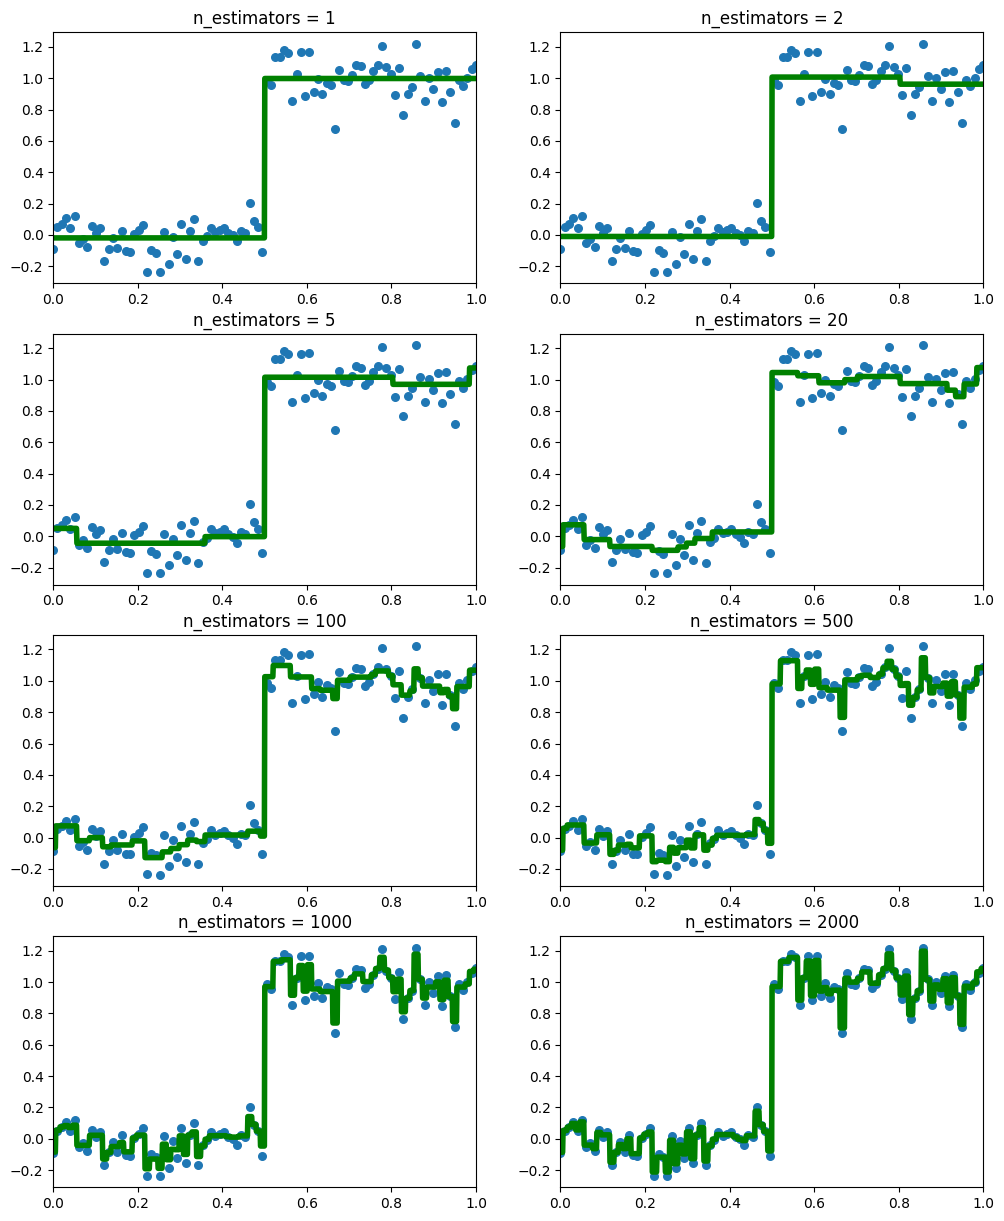

In [6]:
reg = GradientBoostingRegressor(max_depth=1, learning_rate=1, warm_start=True)
plt.figure(figsize=(12, 15))
sizes = [1, 2, 5, 20, 100, 500, 1000, 2000]

for i, s in enumerate(sizes):
  reg.n_estimators = s
  reg.fit(X_train.reshape(-1, 1), y_train)
  plt.subplot(4, 2, i + 1)
  plt.xlim([0, 1])
  plt.scatter(X_train, y_train, s=30)
  y_pred = reg.predict(X_test.reshape(-1, 1))
  plt.plot(X_test, y_pred, c='green', linewidth=4)
  plt.title(f'n_estimators = {s}')
plt.show()

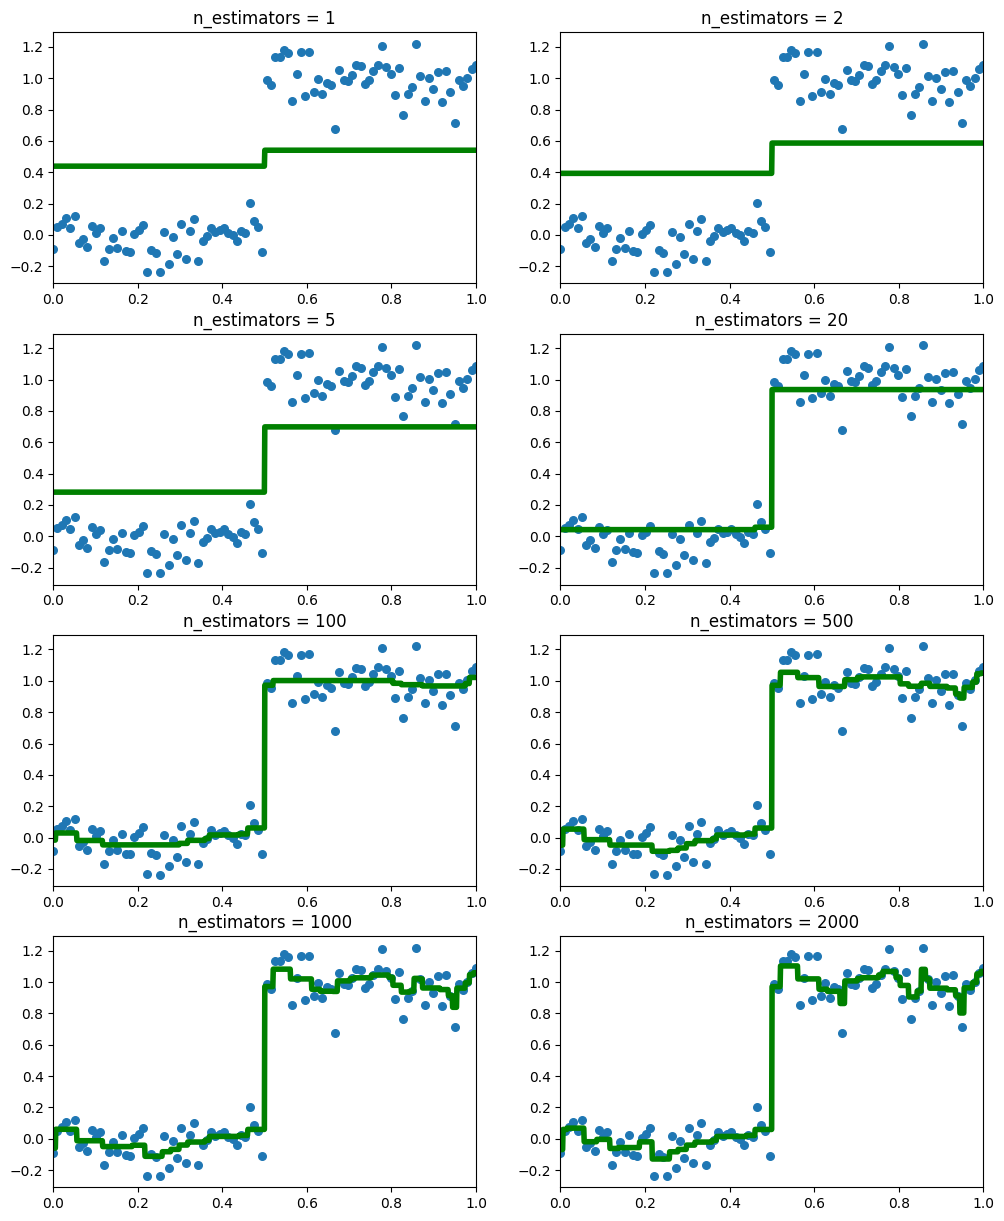

In [7]:
reg = GradientBoostingRegressor(max_depth=1, learning_rate=0.1, warm_start=True)
plt.figure(figsize=(12, 15))
sizes = [1, 2, 5, 20, 100, 500, 1000, 2000]

for i, s in enumerate(sizes):
  reg.n_estimators = s
  reg.fit(X_train.reshape(-1, 1), y_train)
  plt.subplot(4, 2, i + 1)
  plt.xlim([0, 1])
  plt.scatter(X_train, y_train, s=30)
  y_pred = reg.predict(X_test.reshape(-1, 1))
  plt.plot(X_test, y_pred, c='green', linewidth=4)
  plt.title(f'n_estimators = {s}')
plt.show()

In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split

ds = datasets.load_diabetes()
df = pd.DataFrame(ds.data, columns=ds.feature_names)
df['target'] = ds.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


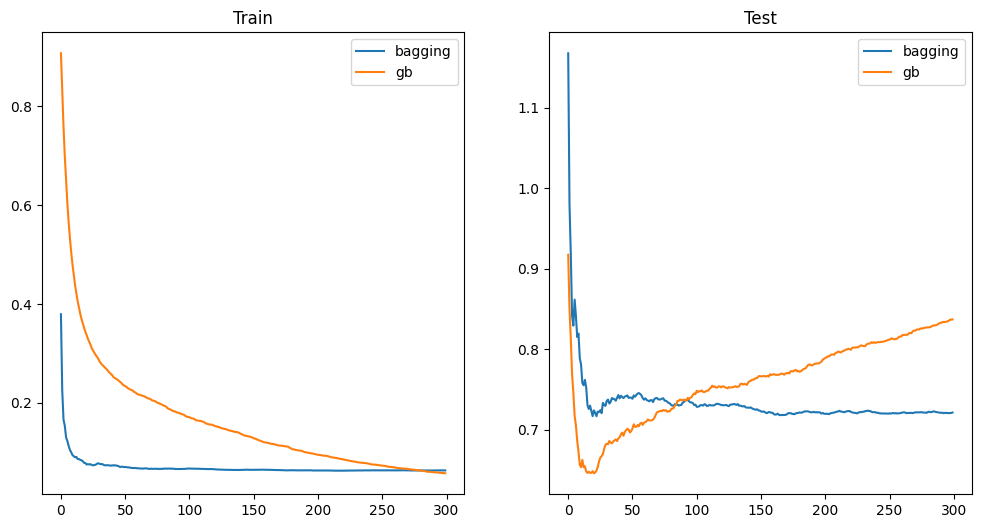

<Figure size 1500x700 with 0 Axes>

In [6]:
X = ds.data
y = ds.target
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, test_size=0.5)

MAX_ESTIMATORS = 300

gbclf = BaggingRegressor(warm_start=True)
err_train, err_test = [], []

for i in range(1, MAX_ESTIMATORS + 1):
  gbclf.n_estimators = i
  gbclf.fit(X_train, y_train)
  err_train.append(1 - gbclf.score(X_train, y_train))
  err_test.append(1 - gbclf.score(X_test, y_test))

gbclf = GradientBoostingRegressor(warm_start=True, max_depth=2, learning_rate=0.1)
err_train_gb, err_test_gb = [], []

for i in range(1, MAX_ESTIMATORS + 1):
  gbclf.n_estimators = i
  gbclf.fit(X_train, y_train)
  err_train_gb.append(1 - gbclf.score(X_train, y_train))
  err_test_gb.append(1 - gbclf.score(X_test, y_test))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(err_train, label='bagging')
plt.plot(err_train_gb, label='gb')
plt.legend()
plt.title('Train')
plt.subplot(1, 2, 2)
plt.plot(err_test, label='bagging')
plt.plot(err_test_gb, label='gb')
plt.legend()
plt.title('Test')
plt.show()
plt.gcf().set_size_inches(15,7)

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import KFold, cross_val_score

data = pd.read_csv('/content/train 2.csv')
data.head()

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=241)

In [11]:
y_test

array([1, 0, 1, ..., 0, 0, 0])

In [12]:
%%time

gdm = GradientBoostingClassifier(n_estimators=250, learning_rate=0.2, verbose=True).fit(X_train, y_train)

      Iter       Train Loss   Remaining Time 
         1           1.2613           24.71s
         2           1.1715           21.84s
         3           1.1009           20.48s
         4           1.0529           19.31s
         5           1.0130           18.41s
         6           0.9740           17.85s
         7           0.9475           18.08s
         8           0.9197           18.21s
         9           0.8979           18.28s
        10           0.8730           18.20s
        20           0.7207           17.16s
        30           0.6055           16.52s
        40           0.5244           15.56s
        50           0.4501           14.73s
        60           0.3908           14.00s
        70           0.3372           13.12s
        80           0.3009           12.29s
        90           0.2603           11.54s
       100           0.2327           10.82s
       200           0.0835            4.03s
CPU times: user 18.5 s, sys: 17.3 ms, total: 18.5 s
Wa

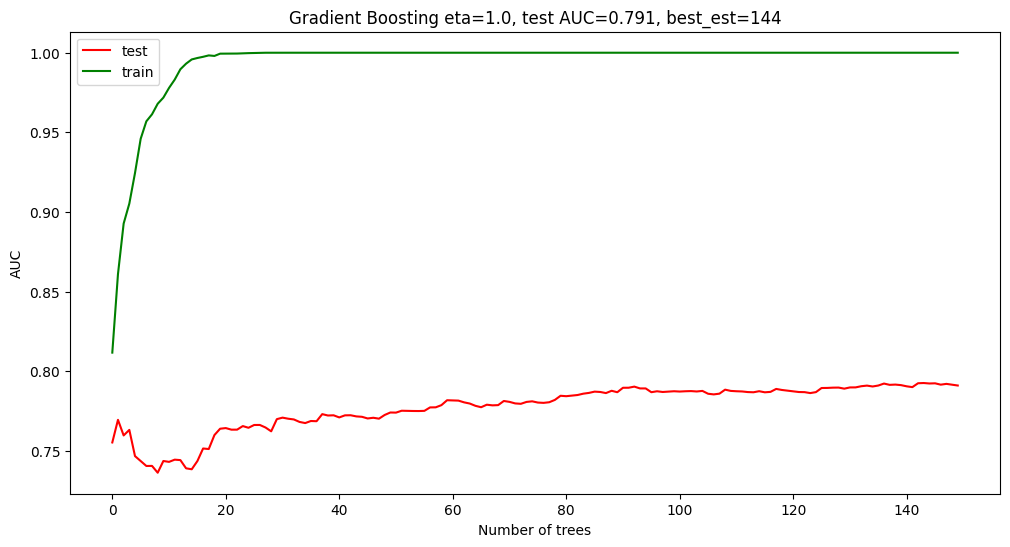

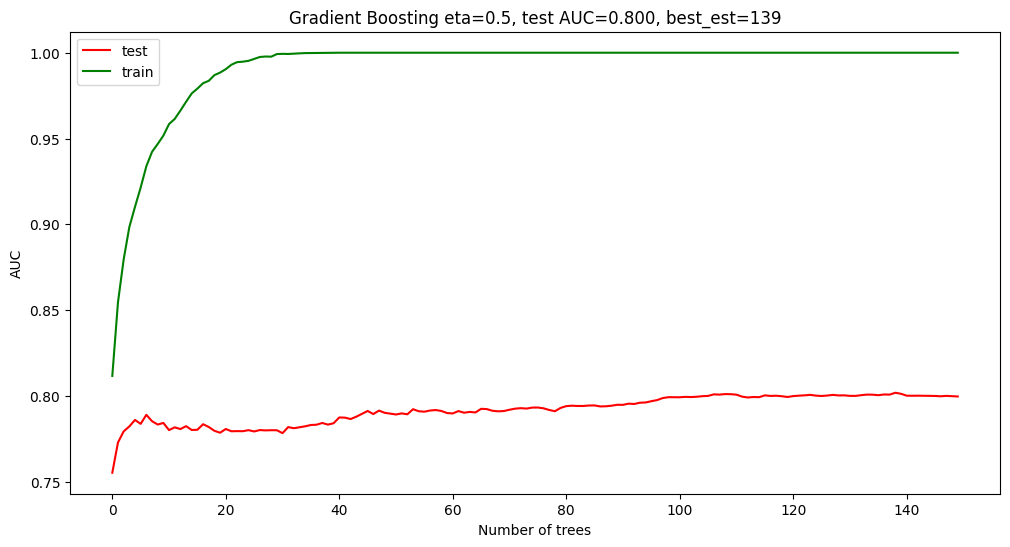

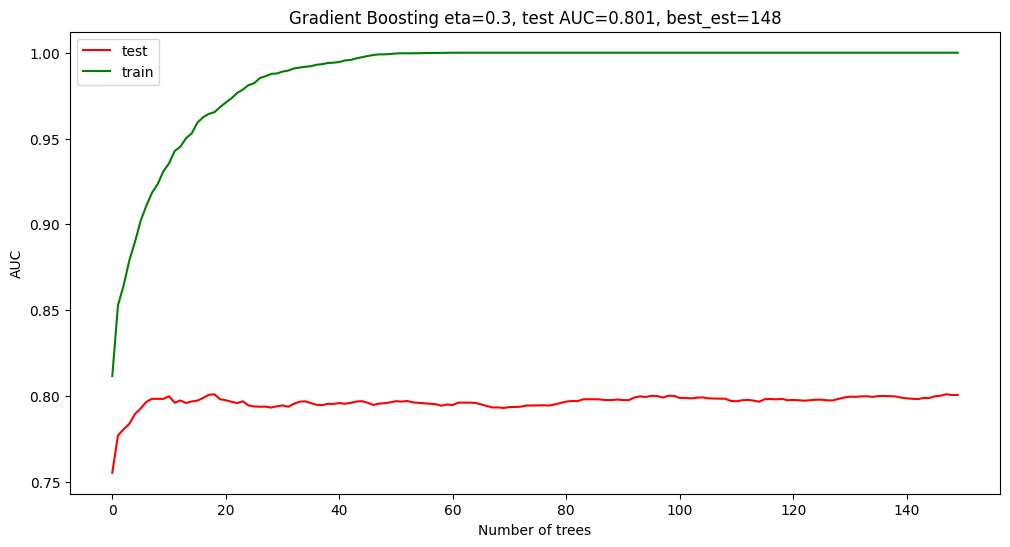

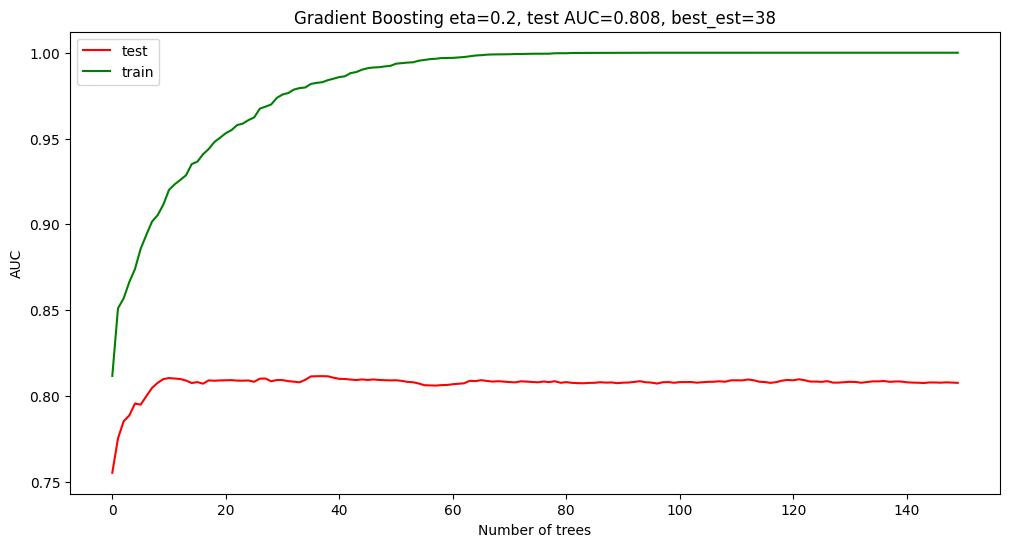

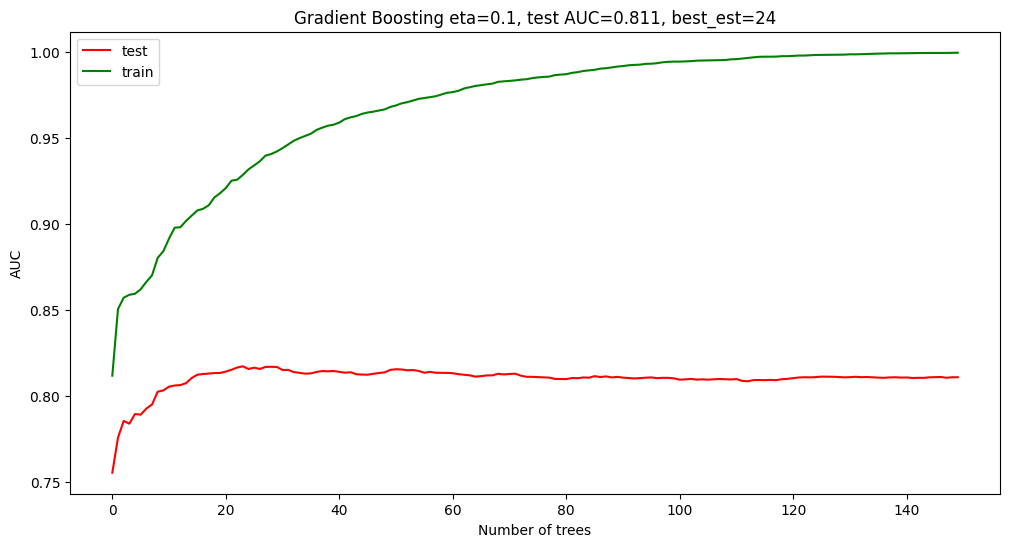

In [13]:
from sklearn.metrics import roc_auc_score

for learning_rate in [1, 0.5, 0.3, 0.2, 0.1]:
  gdm = GradientBoostingClassifier(n_estimators=150, learning_rate=learning_rate, random_state=241).fit(X_train, y_train)
  test_deviance = np.zeros((gdm.n_estimators,), dtype=np.float64)
  for i, y_pred in enumerate(gdm.staged_decision_function(X_test)):
    y_pred = 1 / (1 + np.exp(-y_pred))
    test_deviance[i] = roc_auc_score(y_test, y_pred)

  train_deviance = np.zeros((gdm.n_estimators,), dtype=np.float64)
  for i, y_pred in enumerate(gdm.staged_decision_function(X_train)):
    y_pred = 1 / (1 + np.exp(-y_pred))
    train_deviance[i] = roc_auc_score(y_train, y_pred)

  plt.figure(figsize=(12, 6))
  plt.plot(test_deviance, 'r', label='test')
  plt.plot(train_deviance, 'g', label='train')
  plt.legend()

  plt.title(f'Gradient Boosting eta={learning_rate:.1f}, test AUC={test_deviance[-1]:.3f}, best_est={test_deviance.argmax()+1}')
  plt.xlabel('Number of trees')
  plt.ylabel('AUC')
  plt.show()


In [14]:
rf = RandomForestClassifier(n_estimators=24, random_state=0).fit(X_train, y_train)
print(f"Test AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])}")
print(f"Train AUC: {roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])}")

Test AUC: 0.8037501166053144
Train AUC: 0.9999786482947104


In [15]:
for n_estimators in range(10, 101, 10):
    rf = RandomForestClassifier(n_estimators=n_estimators, n_jobs=4).fit(X_train, y_train)
    print (n_estimators, 'trees: train ROC-AUC =',  roc_auc_score(y_train, rf.predict_proba(X_train)[:,1]), 'test ROC-AUC =',  roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

10 trees: train ROC-AUC = 0.9992420144622217 test ROC-AUC = 0.7703639969431468
20 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.7827938992099542
30 trees: train ROC-AUC = 0.9999999999999999 test ROC-AUC = 0.8080923191182485
40 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.8107899382171226
50 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.815291351832318
60 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.8122246320653851
70 trees: train ROC-AUC = 0.9999999999999999 test ROC-AUC = 0.8239302359373991
80 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.8210568119030703
90 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.8186007003494571
100 trees: train ROC-AUC = 1.0 test ROC-AUC = 0.8247231520748571


In [33]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [34]:
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_surface(X, y, clf):
  h = 0.2
  x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
  y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.figure(figsize=(8,8))
  plt.pcolormesh(xx, yy, Z, cmap=cmap_light)
  plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show()

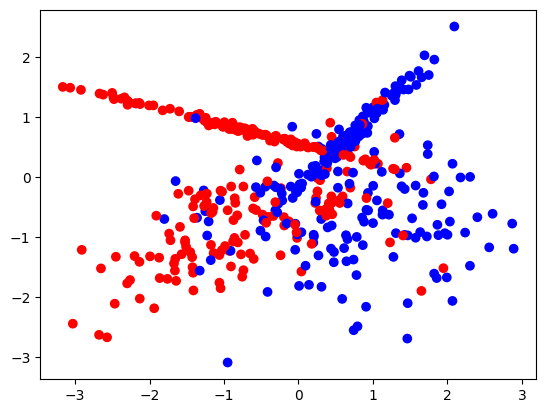

In [35]:
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2,
                           flip_y=0.05, class_sep=0.8, n_clusters_per_class=2, random_state=241)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=241)
plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold)
plt.show()

In [36]:
! pip install lightgbm
! pip install catboost

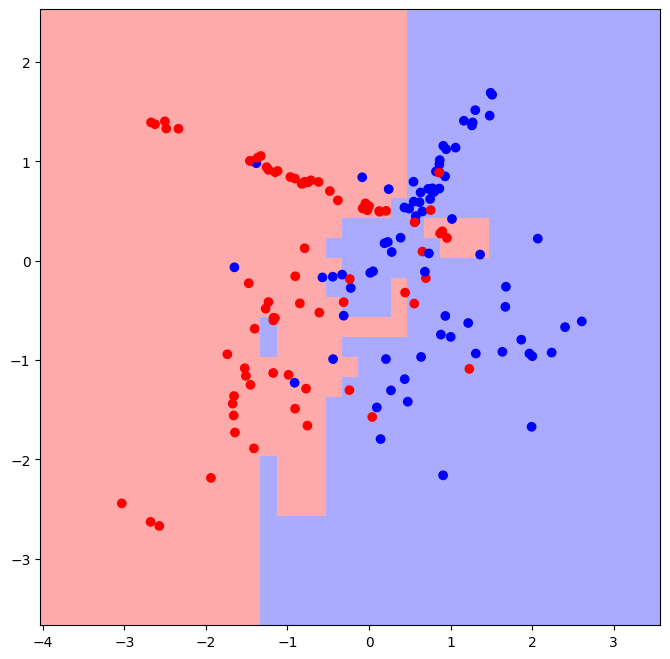

0.919452347083926


In [37]:
from sklearn.metrics import *
from catboost import CatBoostClassifier

clf = CatBoostClassifier(iterations=300, logging_level='Silent')
clf.fit(X_train, y_train)
plot_surface(X_test, y_test, clf)

print(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

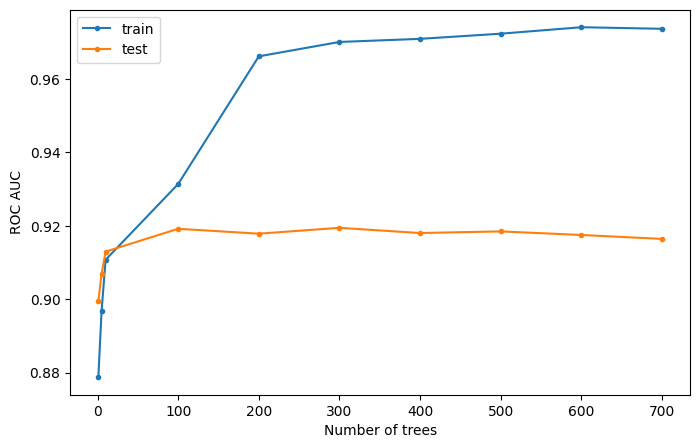

In [38]:
n_trees = [1, 5, 10, 100, 200, 300, 400, 500, 600, 700]
quals_train = []
quals_test = []
for n in n_trees:
  clf = CatBoostClassifier(iterations=n, logging_level='Silent')
  clf.fit(X_train, y_train)
  roc_auc_score_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
  roc_auc_score_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
  quals_train.append(roc_auc_score_train)
  quals_test.append(roc_auc_score_test)

plt.figure(figsize=(8, 5))
plt.plot(n_trees, quals_train, marker='.', label='train')
plt.plot(n_trees, quals_test, marker='.', label='test')
plt.xlabel('Number of trees')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

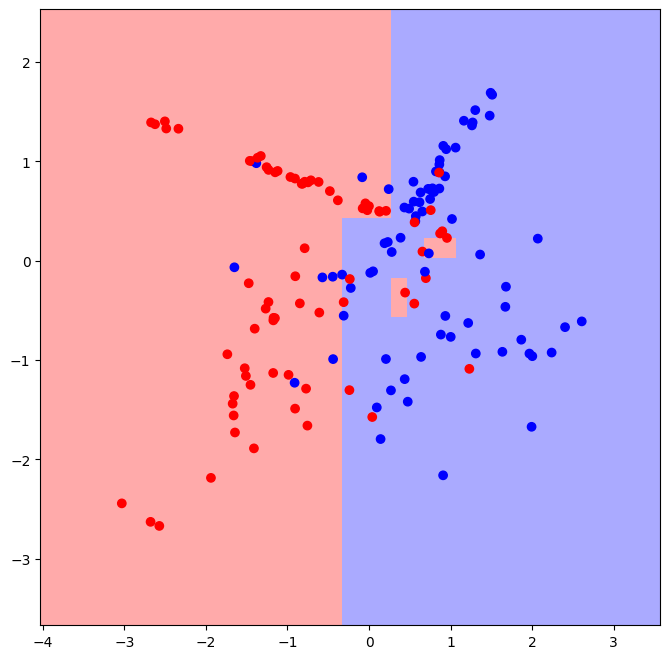

0.9103840682788051


In [39]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

clf = LGBMClassifier(n_estimators=10, verbose=-1)
clf.fit(X_train, y_train)
plot_surface(X_test, y_test, clf)

print(roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1]))

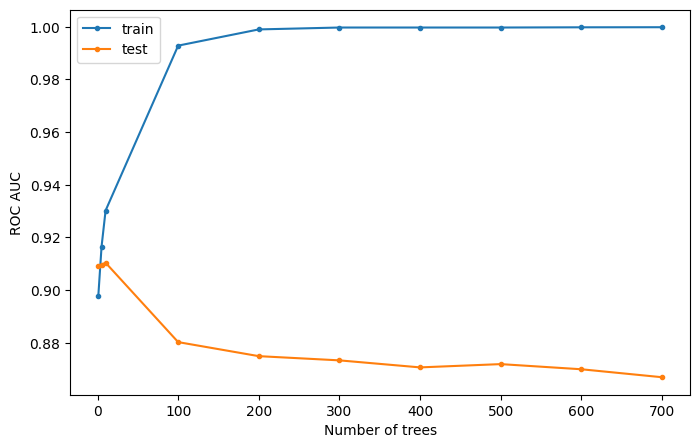

In [27]:
n_trees = [1, 5, 10, 100, 200, 300, 400, 500, 600, 700]
quals_train = []
quals_test = []
for n in n_trees:
    clf = LGBMClassifier(n_estimators=n, verbose=-1)
    clf.fit(X_train, y_train)
    roc_auc_score_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    roc_auc_score_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_train.append(roc_auc_score_train)
    quals_test.append(roc_auc_score_test)

plt.figure(figsize=(8, 5))
plt.plot(n_trees, quals_train, marker='.', label='train')
plt.plot(n_trees, quals_test, marker='.', label='test')
plt.xlabel('Number of trees')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

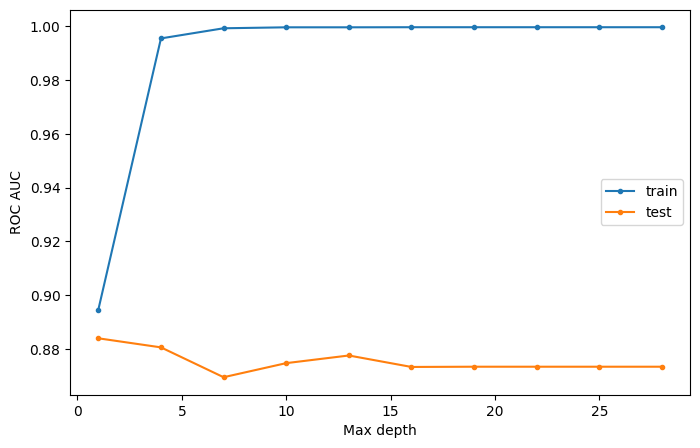

In [40]:
depth_list = list(range(1, 30, 3))
n_trees = 300
quals_train = []
quals_test = []
for d in depth_list:
    lgb = LGBMClassifier(n_estimators=n_trees, max_depth=d, verbose=-1)
    lgb.fit(X_train, y_train)
    roc_auc_score_train = roc_auc_score(y_train, lgb.predict_proba(X_train)[:, 1])
    roc_auc_score_test = roc_auc_score(y_test, lgb.predict_proba(X_test)[:, 1])
    quals_train.append(roc_auc_score_train)
    quals_test.append(roc_auc_score_test)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, quals_train, marker='.', label='train')
plt.plot(depth_list, quals_test, marker='.', label='test')
plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

In [30]:
CatBoostClassifier?

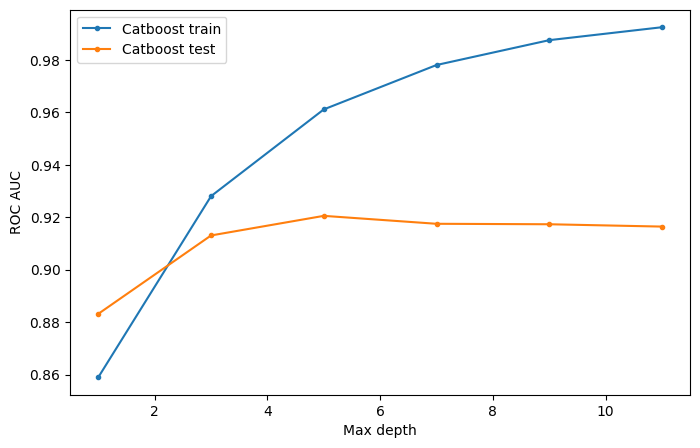

In [41]:
depth_list = list(range(1, 12, 2))
n_trees = 300
quals_cat_train = []
quals_cat_test = []
for d in depth_list:
    clf = CatBoostClassifier(iterations=n_trees, depth=d, logging_level='Silent')
    clf.fit(X_train, y_train)
    roc_auc_score_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    roc_auc_score_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_cat_train.append(roc_auc_score_train)
    quals_cat_test.append(roc_auc_score_test)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, quals_cat_train, marker='.', label='Catboost train')
plt.plot(depth_list, quals_cat_test, marker='.', label='Catboost test')
plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

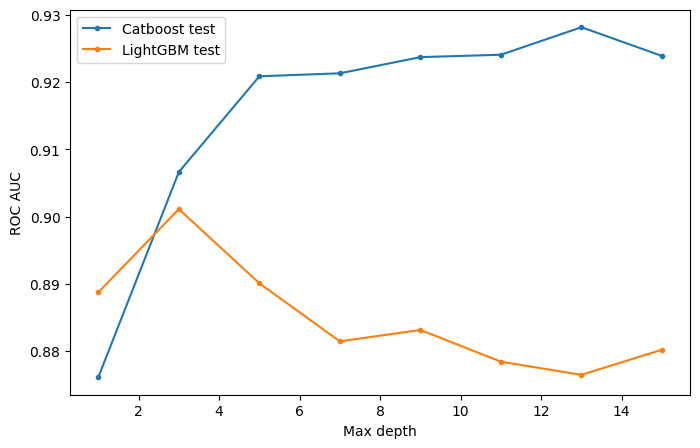

In [42]:
depth_list = list(range(1, 16, 2))
n_trees = 100
quals_cat_train = []
quals_cat_test = []
quals_lgb_train = []
quals_lgb_test = []
for d in depth_list:
    clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
    clf.fit(X_train, y_train)
    q_cat_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    q_cat_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_cat_train.append(q_cat_train)
    quals_cat_test.append(q_cat_test)

    lgb = LGBMClassifier(n_estimators=n_trees, max_depth=d, verbose=-1)
    lgb.fit(X_train, y_train)
    q_lgb_train = roc_auc_score(y_train, lgb.predict_proba(X_train)[:, 1])
    q_lgb_test = roc_auc_score(y_test, lgb.predict_proba(X_test)[:, 1])
    quals_lgb_train.append(q_lgb_train)
    quals_lgb_test.append(q_lgb_test)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, quals_cat_test, marker='.', label='Catboost test')
plt.plot(depth_list, quals_lgb_test, marker='.', label='LightGBM test')
plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

In [43]:
print(f'{np.max(quals_cat_test):.3f}')
print(f'{np.max(quals_lgb_test):.3f}')

0.928
0.901


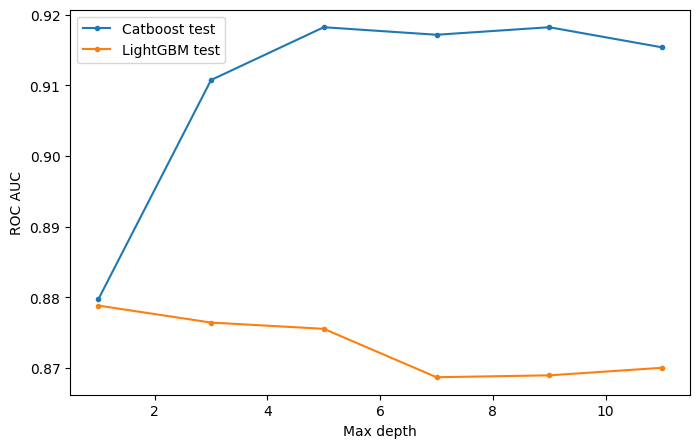

In [44]:
depth_list = list(range(1, 12, 2))
n_trees = 500
quals_cat_train = []
quals_cat_test = []
quals_lgb_train = []
quals_lgb_test = []
for d in depth_list:
    clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
    clf.fit(X_train, y_train)
    q_cat_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    q_cat_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_cat_train.append(q_cat_train)
    quals_cat_test.append(q_cat_test)

    lgb = LGBMClassifier(n_estimators=n_trees, max_depth=d, verbose=-1)
    lgb.fit(X_train, y_train)
    q_lgb_train = roc_auc_score(y_train, lgb.predict_proba(X_train)[:, 1])
    q_lgb_test = roc_auc_score(y_test, lgb.predict_proba(X_test)[:, 1])
    quals_lgb_train.append(q_lgb_train)
    quals_lgb_test.append(q_lgb_test)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, quals_cat_test, marker='.', label='Catboost test')
plt.plot(depth_list, quals_lgb_test, marker='.', label='LightGBM test')
plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

In [49]:
! pip install xgboost

In [50]:
from xgboost import XGBClassifier

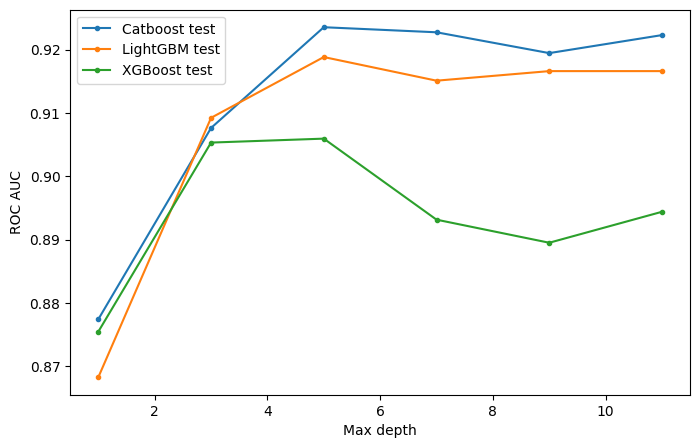

In [51]:
depth_list = list(range(1, 12, 2))
n_trees = 20
quals_cat_train = []
quals_cat_test = []
quals_lgb_train = []
quals_lgb_test = []
quals_xgb_train = []
quals_xgb_test = []

for d in depth_list:
    clf = CatBoostClassifier(n_estimators=n_trees, max_depth=d, logging_level="Silent")
    clf.fit(X_train, y_train)
    q_cat_train = roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1])
    q_cat_test = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    quals_cat_train.append(q_cat_train)
    quals_cat_test.append(q_cat_test)

    lgb = LGBMClassifier(n_estimators=n_trees, max_depth=d, verbose=-1)
    lgb.fit(X_train, y_train)
    q_lgb_train = roc_auc_score(y_train, lgb.predict_proba(X_train)[:, 1])
    q_lgb_test = roc_auc_score(y_test, lgb.predict_proba(X_test)[:, 1])
    quals_lgb_train.append(q_lgb_train)
    quals_lgb_test.append(q_lgb_test)

    xgb = XGBClassifier(n_estimators=n_trees, max_depth=d)
    xgb.fit(X_train, y_train)
    q_xgb_train = roc_auc_score(y_train, xgb.predict_proba(X_train)[:, 1])
    q_xgb_test = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
    quals_xgb_train.append(q_xgb_train)
    quals_xgb_test.append(q_xgb_test)

plt.figure(figsize=(8, 5))
plt.plot(depth_list, quals_cat_test, marker='.', label='Catboost test')
plt.plot(depth_list, quals_lgb_test, marker='.', label='LightGBM test')
plt.plot(depth_list, quals_xgb_test, marker='.', label='XGBoost test')
plt.xlabel('Max depth')
plt.ylabel('ROC AUC')
plt.legend()
plt.show()

In [52]:
print(f'{np.max(quals_cat_test):.3f}')
print(f'{np.max(quals_lgb_test):.3f}')
print(f'{np.max(quals_xgb_test):.3f}')

0.924
0.919
0.906


In [20]:
lgb.booster_.save_model('lgbm.txt')
clf.save_model('catboost.cbm', format='cbm')

In [21]:
lgb = LGBMClassifier(model_file='lgbm.txt')
clf = clf.load_model('catboost.cbm')